In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from go_ml.eval_utils import filter_annot_df
from go_ml.eval_utils import (load_msa_dict, gen_pssm_mat, get_pssm_entropy, 
                              gen_annot_mat, gen_seq_len_mask, mean_reciprocal_rank, 
                              mean_reciprocal_rank_mat, mean_auc, top_30_score, roc_average)

In [ ]:
# Run from go_ml/dataset_eval/
msa_root = '../msa_pipeline/uniref_msa'
data_root = '../gen_datasets/datasets'

# Datasets with precomputed MSA alignments (in {msa_root}/{label}_msa_output/)
ds_labels = ['csa', 'llps', 'elms', 'ip_domain']
ds_dir = [f'{msa_root}/{label}_msa_output' for label in ds_labels]
label_df = [filter_annot_df(pd.read_csv(f'{data_root}/{label}_dataset.csv', sep='\t')) for label in ds_labels]

In [10]:
from Bio import SeqIO
for i, (pid, seq) in enumerate(zip(label_df[0]['UniprotID'], label_df[0]['Sequence'])):
    msa_path = f'{ds_dir[0]}/ipdom{i}_homologues_aligned.fasta'
    prot_rec_l = list(SeqIO.parse(msa_path, 'fasta'))
    prot_id_l = [rec.id for rec in prot_rec_l]
    prot_seq_l = [str(rec.seq).replace('-', '') for rec in prot_rec_l]
    # print(prot_seq_l)
    print(seq in prot_seq_l)
    # break

True
True
True
False
False
True
False
False
False
True
True
False
True
True
True
True
True
False
False
False
False
False
True
True
True
True
True
False
True
True
True
True
True
True
True
False
True
True
True
True
True
True
True
False
False
True
True
True
True
True
True
True
False
False
True
True
True
True
True
True
True
False
True
True
False
True
True
False
True
True
True
True
True
False
True
False
False
False
False
True
True
True
True
False
True
True
False
True
False
True
True
True
False
True
True
True
True
False
True
True
False
True
True
False
False
False
True
True
True
False
True
True
False
False
False
False
False
False
True
False
False
False
True
True
True
False
True
True
True
True
True
False
False
False
True
True
True
False
True
False
True
True
False
True
False
False
True
False
False
False
False
True
True
False
True
True
True
True
False
True
True
False
True
True
True
False
True
True
False
True
False
True
True
False
True
True
False
False
True


In [ ]:
msa_ip_id = [f'ipdom{i}' for i in range(len(label_df[0]))]

msa_dir = ds_dir[0]
msa_dict = load_msa_dict(msa_ip_id, msa_dir)
pssm_mat = gen_pssm_mat(msa_ip_id, msa_dict, max_len=850)

In [12]:
annot_df = label_df[0]
annot_mat = gen_annot_mat(annot_df['AnnotatedIndices'], [len(s) for s in annot_df['Sequence']])
seq_len_mask = gen_seq_len_mask(annot_df['Sequence'])
pssm_entropy = get_pssm_entropy(pssm_mat, seq_len_mask)
ds_label = ds_labels[0]

import pickle
with open(f'eval_files/{ds_label}_msa.pkl', 'wb') as f:
    pickle.dump({'UniprotID': annot_df['UniprotID'], 'pssm': pssm_mat, 
                     'seq_len_mask': seq_len_mask, 'pssm_entropy': pssm_entropy}, f)
    print(f'MSA Directory: {msa_dir}')

MSA Directory: /home/andrew/GO_interp/go_ml/msa_benchmark/uniref_msa/ip_domain_msa_output


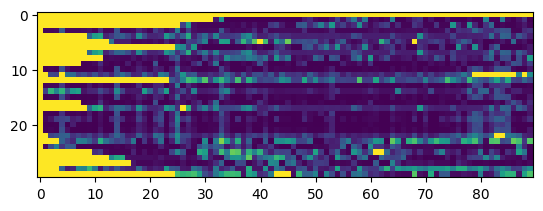

In [18]:
import matplotlib.pyplot as plt
plt.imshow(pssm_entropy[:30, :90])

In [ ]:
import pickle, os

def build_pssm_mat(seq_ids, msa_dir):
    msa_dict = load_msa_dict(seq_ids, msa_dir)
    pssm_mat = gen_pssm_mat(seq_ids, msa_dict, max_len=850)
    return pssm_mat

for ds_label, msa_dir, annot_df in zip(ds_labels, ds_dir, label_df):
    # ip_domain FASTAs use ipdom{i} IDs; all others use UniprotID
    if ds_label == 'ip_domain':
        seq_ids = [f'ipdom{i}' for i in range(len(annot_df))]
    else:
        seq_ids = list(annot_df['UniprotID'])

    pssm_mat = build_pssm_mat(seq_ids, msa_dir)
    annot_mat = gen_annot_mat(annot_df['AnnotatedIndices'], [len(s) for s in annot_df['Sequence']])
    seq_len_mask = gen_seq_len_mask(annot_df['Sequence'])
    pssm_entropy = get_pssm_entropy(pssm_mat, seq_len_mask)

    save_path = f'eval_files/{ds_label}/msa.pkl'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    with open(save_path, 'wb') as f:
        pickle.dump({'UniprotID': annot_df['UniprotID'], 'pssm': pssm_mat,
                     'seq_len_mask': seq_len_mask, 'pssm_entropy': pssm_entropy}, f)
    print(f'Saved {save_path}')